In [1]:
import numpy as np
import pandas as pd


In [2]:
# Set pandas options to display all columns and rows clearly
pd.set_option('display.max_columns', None)

In [3]:
data = pd.read_csv('fuel_processed_data.csv')

In [4]:
# Group by Country to prevent border leakage between different countries
grouped = data.groupby('Country')

# Create future scarcity label (predicting next week's scarcity)
data['Scarcity_Target'] = (
    (grouped['Demand_Index'].shift(-1) > grouped['Supply_Index'].shift(-1)) &
    (grouped['Supply_Index'].shift(-1) < 40)
).astype(int)

# Add Lag-1 features (previous week's momentum at t-1)
data['Supply_Index_lag_1'] = grouped['Supply_Index'].shift(1)
data['Demand_Index_lag_1'] = grouped['Demand_Index'].shift(1)

# Supply-Demand Ratio Lag (Past balance ratio)
data['Supply_Demand_Ratio_lag_1'] = data['Supply_Index_lag_1'] / (data['Demand_Index_lag_1'] + 1e-5)



In [5]:
# Encoding for Subsidy_Level
subsidy_map = {'Low': 0, 'Medium': 1, 'High': 2}
data['Subsidy_Level_Encoded'] = data['Subsidy_Level'].map(subsidy_map)

In [6]:
data

,Date,Country,Region,Petrol_Price_USD_per_Liter,Diesel_Price_USD_per_Liter,Natural_Gas_Price_USD_per_MMBtu,Crude_Oil_Price_USD_per_Barrel,Inflation_Rate (%),Exchange_Rate_vs_USD,GDP_Growth (%),Supply_Index,Demand_Index,Geopolitical_Risk_Index,Event_Flag,Event_Description,Currency_Devaluation (%),Subsidy_Level,Tax_Rate_on_Fuel (%),Petrol_7d_MA,Petrol_28d_vol,Petrol_lag_1,Crude_lag_1,Scarcity_Flag,Year,Month,Quarter,Week,Day_Of_Week,Scarcity_Target,Supply_Index_lag_1,Demand_Index_lag_1,Supply_Demand_Ratio_lag_1,Subsidy_Level_Encoded
0,2015-01-05,Brazil,Latin America,0.675,0.609,1.769,50.91,2.42,5.1316,0.58,46.7,53.9,20.4,0,No Event,0.32,Medium,20.0,0.675000,0.011102,0.675,50.91,0,2015,1,1,2,0,1,NaN,NaN,NaN,1
1,2015-01-12,Brazil,Latin America,0.687,0.602,1.565,51.57,3.39,5.2201,2.08,39.9,67.4,23.5,0,No Event,-0.41,Medium,20.0,0.681000,0.011102,0.675,50.91,1,2015,1,1,3,0,0,46.7,53.9,0.866419,1
2,2015-01-19,Brazil,Latin America,0.710,0.642,1.760,53.96,2.03,5.0857,3.43,60.2,53.8,21.1,0,No Event,0.35,Medium,20.0,0.690667,0.011102,0.687,51.57,0,2015,1,1,4,0,0,39.9,67.4,0.591988,1
3,2015-01-26,Brazil,Latin America,0.802,0.713,1.500,58.69,2.30,5.2486,1.96,49.1,63.8,24.5,0,No Event,-0.46,Medium,20.0,0.718500,0.060526,0.710,53.96,0,2015,1,1,5,0,0,60.2,53.8,1.118959,1
4,2015-02-02,Brazil,Latin America,0.685,0.650,1.500,52.61,1.96,5.2284,1.83,45.2,53.8,25.4,0,No Event,-0.74,Medium,20.0,0.721000,0.114316,0.802,58.69,0,2015,2,1,6,0,0,49.1,63.8,0.769592,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5855,2026-02-23,United States,North America,0.999,0.892,2.424,69.89,2.72,4.6284,1.72,59.1,50.2,24.4,0,No Event,0.31,Low,18.0,0.985250,0.069283,1.083,72.97,0,2026,2,1,9,0,0,43.2,54.7,0.789762,0
5856,2026-03-02,United States,North America,1.016,0.915,2.039,72.38,2.59,4.5533,-1.07,51.6,51.5,29.5,0,No Event,0.67,Low,18.0,1.012250,0.063739,0.999,69.89,0,2026,3,1,10,0,0,59.1,50.2,1.177291,0
5857,2026-03-09,United States,North America,1.108,0.991,2.509,77.52,2.63,4.5467,3.78,57.3,52.9,25.3,0,No Event,-0.58,Low,18.0,1.051500,0.066745,1.016,72.38,0,2026,3,1,11,0,0,51.6,51.5,1.001942,0
5858,2026-03-16,United States,North America,1.042,0.960,2.110,73.20,3.12,4.5351,1.79,50.8,60.6,27.4,0,No Event,-0.86,Low,18.0,1.041250,0.069837,1.108,77.52,0,2026,3,1,12,0,0,57.3,52.9,1.083176,0


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5860 entries, 0 to 5859
Data columns (total 33 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Date                             5860 non-null   object 
 1   Country                          5860 non-null   object 
 2   Region                           5860 non-null   object 
 3   Petrol_Price_USD_per_Liter       5860 non-null   float64
 4   Diesel_Price_USD_per_Liter       5860 non-null   float64
 5   Natural_Gas_Price_USD_per_MMBtu  5860 non-null   float64
 6   Crude_Oil_Price_USD_per_Barrel   5860 non-null   float64
 7   Inflation_Rate (%)               5860 non-null   float64
 8   Exchange_Rate_vs_USD             5860 non-null   float64
 9   GDP_Growth (%)                   5860 non-null   float64
 10  Supply_Index                     5860 non-null   float64
 11  Demand_Index                     5860 non-null   float64
 12  Geopolitical_Risk_In

In [8]:
# List of columns to drop
cols_to_remove = [
    'Date',
    'Scarcity_Flag',
    'Country',
    'Region',
    'Event_Description',
    'Subsidy_Level',
]

# Drop the columns
data.drop(columns=cols_to_remove, inplace=True)


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5860 entries, 0 to 5859
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Petrol_Price_USD_per_Liter       5860 non-null   float64
 1   Diesel_Price_USD_per_Liter       5860 non-null   float64
 2   Natural_Gas_Price_USD_per_MMBtu  5860 non-null   float64
 3   Crude_Oil_Price_USD_per_Barrel   5860 non-null   float64
 4   Inflation_Rate (%)               5860 non-null   float64
 5   Exchange_Rate_vs_USD             5860 non-null   float64
 6   GDP_Growth (%)                   5860 non-null   float64
 7   Supply_Index                     5860 non-null   float64
 8   Demand_Index                     5860 non-null   float64
 9   Geopolitical_Risk_Index          5860 non-null   float64
 10  Event_Flag                       5860 non-null   int64  
 11  Currency_Devaluation (%)         5860 non-null   float64
 12  Tax_Rate_on_Fuel (%)

In [10]:
data.dropna(inplace=True)

In [11]:
# Sort dataset chronologically using extracted date components
data = data.sort_values(by=['Year', 'Month', 'Quarter', 'Week']).reset_index(drop=True)

# Verify dataset is cleanly sorted
print("Dataset successfully sorted chronologically.")
data[['Year', 'Month', 'Quarter', 'Week']].head()

Dataset successfully sorted chronologically.


,Year,Month,Quarter,Week
0,2015,1,1,3
1,2015,1,1,3
2,2015,1,1,3
3,2015,1,1,3
4,2015,1,1,3


In [12]:
# Separate features (X) and target (y)
y = data['Scarcity_Target']
X = data.drop(columns=['Scarcity_Target'])

# Chronological 80/20 Split
split_idx = int(len(data) * 0.80)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training set: {len(X_train)} rows | Testing set: {len(X_test)} rows")

Training set: 4680 rows | Testing set: 1170 rows


In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Scale features for linear models (fit ONLY on training set to avoid data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Baseline Model (Logistic Regression)
baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train_scaled, y_train)

# Train Primary Model (Random Forest Classifier)
# class_weight='balanced' addresses any class imbalance in scarcity events
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

# Generate Predictions & Probabilities (Scarcity Likelihood)
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("=== MODEL TRAINING COMPLETE ===")
print(f"Random Forest ROC-AUC Score: {roc_auc_score(y_test, y_prob_rf):.4f}")

=== MODEL TRAINING COMPLETE ===
Random Forest ROC-AUC Score: 0.6601


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      1042
           1       0.00      0.00      0.00       128

    accuracy                           0.89      1170
   macro avg       0.45      0.50      0.47      1170
weighted avg       0.79      0.89      0.84      1170



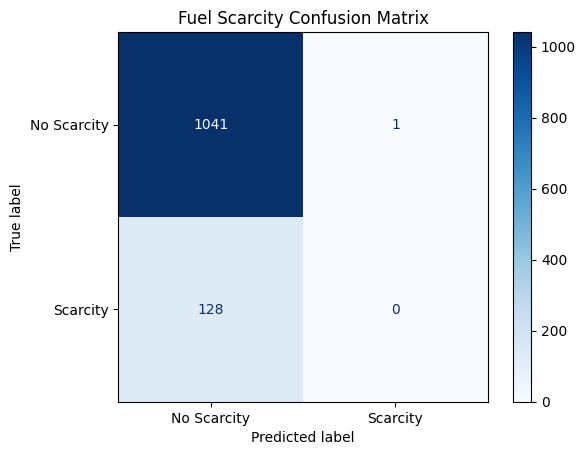

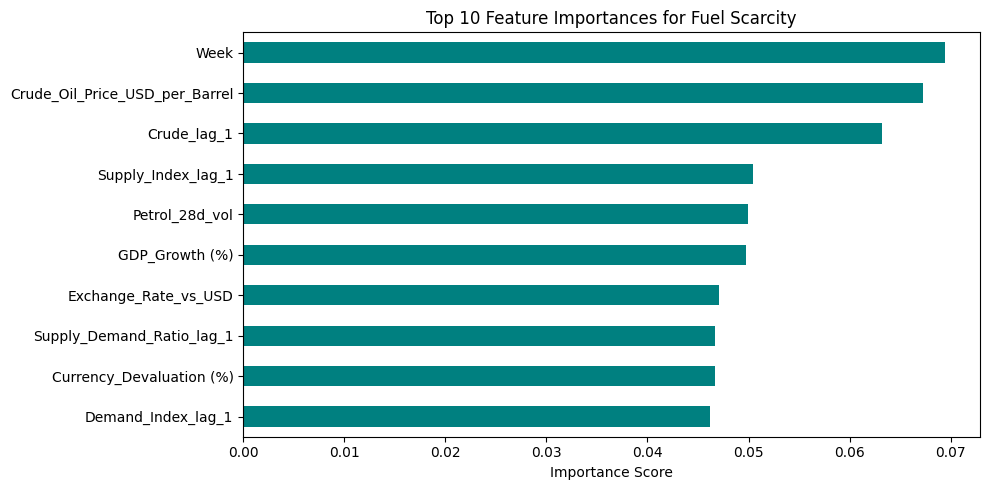

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Print detailed Classification Report (Precision, Recall, F1-Score)
print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred_rf))

# Display Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Scarcity', 'Scarcity'])
disp.plot(cmap='Blues')
plt.title('Fuel Scarcity Confusion Matrix')
plt.show()

# Plot Top 10 Drivers of Fuel Scarcity
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importances.head(10).plot(kind='barh', color='teal')
plt.title('Top 10 Feature Importances for Fuel Scarcity')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [15]:
# Lower the decision threshold to catch rare scarcity events (Class 1)
threshold = 0.20  # Predicts scarcity if model likelihood is >= 20%
y_pred_threshold = (y_prob_rf >= threshold).astype(int)

print(f"=== ADJUSTED THRESHOLD CLASSIFICATION REPORT (Threshold = {threshold}) ===")
print(classification_report(y_test, y_pred_threshold))

# Train a Balanced Random Forest model (Handles heavy class imbalance)
from imblearn.ensemble import BalancedRandomForestClassifier

brf_model = BalancedRandomForestClassifier(n_estimators=100, random_state=42)
brf_model.fit(X_train, y_train)

# Predict using Balanced Random Forest
y_pred_brf = brf_model.predict(X_test)
y_prob_brf = brf_model.predict_proba(X_test)[:, 1]

print("\n=== BALANCED RANDOM FOREST CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred_brf))
print(f"Balanced Random Forest ROC-AUC Score: {roc_auc_score(y_test, y_prob_brf):.4f}")

=== ADJUSTED THRESHOLD CLASSIFICATION REPORT (Threshold = 0.2) ===
              precision    recall  f1-score   support

           0       0.90      0.90      0.90      1042
           1       0.21      0.21      0.21       128

    accuracy                           0.83      1170
   macro avg       0.56      0.56      0.56      1170
weighted avg       0.83      0.83      0.83      1170


=== BALANCED RANDOM FOREST CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.92      0.87      0.89      1042
           1       0.27      0.40      0.32       128

    accuracy                           0.82      1170
   macro avg       0.60      0.63      0.61      1170
weighted avg       0.85      0.82      0.83      1170

Balanced Random Forest ROC-AUC Score: 0.7034


In [16]:
# Predict probabilities using your trained Balanced Random Forest
y_prob_brf = brf_model.predict_proba(X_test)[:, 1]

# Try lower thresholds (e.g., 0.30 or 0.25)
for t in [0.40, 0.35, 0.30, 0.25]:
    y_pred_custom = (y_prob_brf >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_custom)
    scarcity_caught = cm[1, 1]  # True Positives
    total_scarcity = cm[1, 0] + cm[1, 1]  # Total actual scarcity events (128)

    print(f"=== THRESHOLD: {t} ===")
    print(f"Caught {scarcity_caught} out of {total_scarcity} scarcity events (Recall: {scarcity_caught/total_scarcity:.1%})")
    print(classification_report(y_test, y_pred_custom))
    print("-" * 50)

=== THRESHOLD: 0.4 ===
Caught 78 out of 128 scarcity events (Recall: 60.9%)
              precision    recall  f1-score   support

           0       0.94      0.69      0.80      1042
           1       0.20      0.61      0.30       128

    accuracy                           0.68      1170
   macro avg       0.57      0.65      0.55      1170
weighted avg       0.85      0.68      0.74      1170

--------------------------------------------------
=== THRESHOLD: 0.35 ===
Caught 94 out of 128 scarcity events (Recall: 73.4%)
              precision    recall  f1-score   support

           0       0.95      0.57      0.71      1042
           1       0.17      0.73      0.28       128

    accuracy                           0.59      1170
   macro avg       0.56      0.65      0.49      1170
weighted avg       0.86      0.59      0.66      1170

--------------------------------------------------
=== THRESHOLD: 0.3 ===
Caught 106 out of 128 scarcity events (Recall: 82.8%)
              

In [17]:
# Select optimal decision threshold (0.40)
optimal_threshold = 0.40

# Generate final scarcity predictions
y_pred_final = (y_prob_brf >= optimal_threshold).astype(int)

# Print Final Summary
print("=== FINAL MVP MODEL EVALUATION (Threshold = 0.40) ===")
print(f"Scarcity Events Caught: {(y_pred_final & y_test).sum()} / {y_test.sum()} (Recall: {((y_pred_final & y_test).sum() / y_test.sum()):.1%})")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_final))

=== FINAL MVP MODEL EVALUATION (Threshold = 0.40) ===
Scarcity Events Caught: 78 / 128 (Recall: 60.9%)

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.69      0.80      1042
           1       0.20      0.61      0.30       128

    accuracy                           0.68      1170
   macro avg       0.57      0.65      0.55      1170
weighted avg       0.85      0.68      0.74      1170



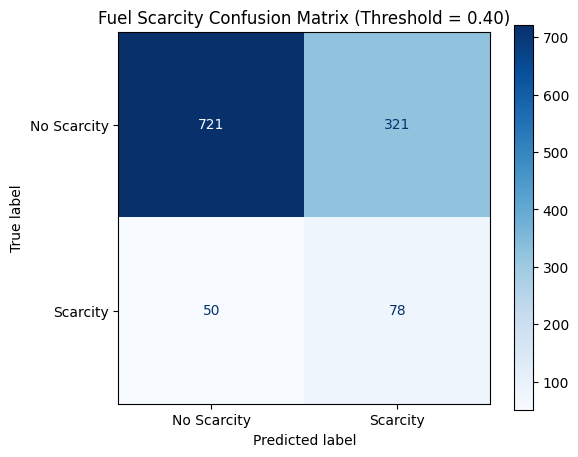

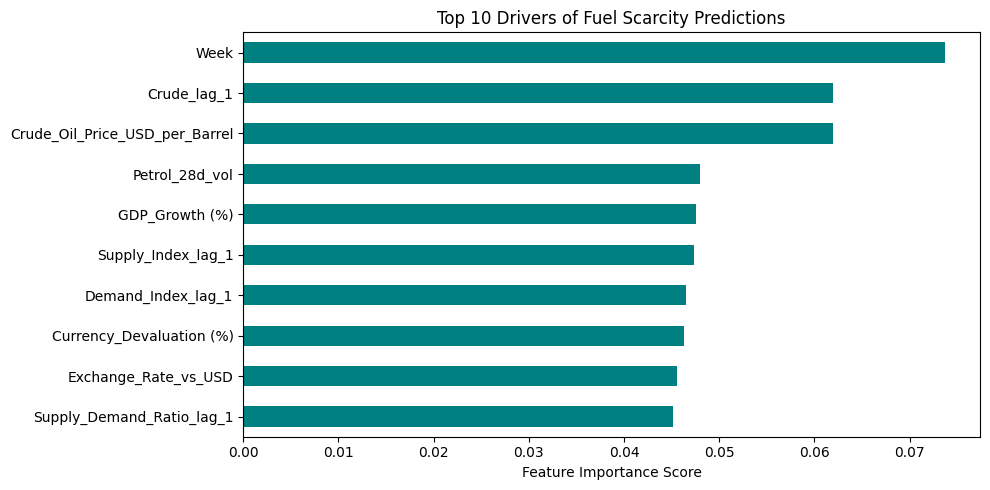

In [18]:
# Plot Confusion Matrix for Final Model (Threshold = 0.40)
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Scarcity', 'Scarcity'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax)
plt.title('Fuel Scarcity Confusion Matrix (Threshold = 0.40)')
plt.show()

# Plot Top 10 Feature Importances from Balanced Random Forest
importances = pd.Series(brf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importances.head(10).plot(kind='barh', color='teal')
plt.title('Top 10 Drivers of Fuel Scarcity Predictions')
plt.xlabel('Feature Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [19]:
import joblib

# Save the trained Balanced Random Forest model
joblib.dump(brf_model, 'fuel_scarcity_model.pkl')

# Save the fitted scaler (if needed for linear models)
joblib.dump(scaler, 'scaler.pkl')

print("=== MODEL ARTIFACTS SAVED SUCCESSFULLY ===")

=== MODEL ARTIFACTS SAVED SUCCESSFULLY ===
